In [740]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

import re


In [741]:
analysis_df = pd.read_csv('../data/processed/analysis_multi.csv',
                          header=[0, 1], index_col=0)
analysis_df.index = pd.to_datetime(analysis_df.index)
analysis_df.columns

MultiIndex([(  'PX', 'ESH1'),
            (  'PX', 'ESM1'),
            (  'PX', 'ESU1'),
            (  'PX', 'ESZ1'),
            (  'PX', 'ESH2'),
            (  'PX', 'ESM2'),
            (  'PX', 'ESU2'),
            (  'PX', 'ESZ2'),
            (  'PX', 'ESH3'),
            (  'PX', 'ESM3'),
            (  'PX', 'ESU3'),
            (  'PX', 'ESZ3'),
            (  'PX', 'ESH4'),
            (  'PX', 'ESM4'),
            (  'PX', 'ESU4'),
            (  'PX', 'ESZ4'),
            (  'PX', 'ESH5'),
            (  'PX', 'ESM5'),
            (  'PX', 'ESU5'),
            (  'PX', 'ESZ5'),
            (  'PX', 'ESH6'),
            (  'PX', '^SPX'),
            (  'PX',   '1M'),
            (  'PX',   '3M'),
            (  'PX',   '6M'),
            (  'PX',  '12M'),
            (  'PX',    'q'),
            (   'T', 'ESZ1'),
            (   'T', 'ESH2'),
            (   'T', 'ESM2'),
            (   'T', 'ESU2'),
            (   'T', 'ESZ2'),
            (   'T', 'ESH3'),
          

In [742]:
unique_cols = analysis_df.columns.get_level_values(1).unique()
unique_cols

Index(['ESH1', 'ESM1', 'ESU1', 'ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3',
       'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5',
       'ESU5', 'ESZ5', 'ESH6', '^SPX', '1M', '3M', '6M', '12M', 'q'],
      dtype='str', name='contract')

In [743]:
futures = [
    c for c in unique_cols
    if re.fullmatch(r'ES[HMUZ]\d+', c)
]
print(futures)

['ESH1', 'ESM1', 'ESU1', 'ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3', 'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5', 'ESU5', 'ESZ5', 'ESH6']


In [744]:
analysis_df['Fair'].columns
# 'ESH1', 'ESM1', 'ESU1' are not exist so we won't include them in our strategy

Index(['ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3', 'ESM3', 'ESU3', 'ESZ3',
       'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5', 'ESU5', 'ESZ5', 'ESH6'],
      dtype='str', name='contract')

In [745]:
exclude = ['ESH1', 'ESM1', 'ESU1']
futures = [f for f in futures if f not in exclude]
print(futures)

['ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3', 'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5', 'ESU5', 'ESZ5', 'ESH6']


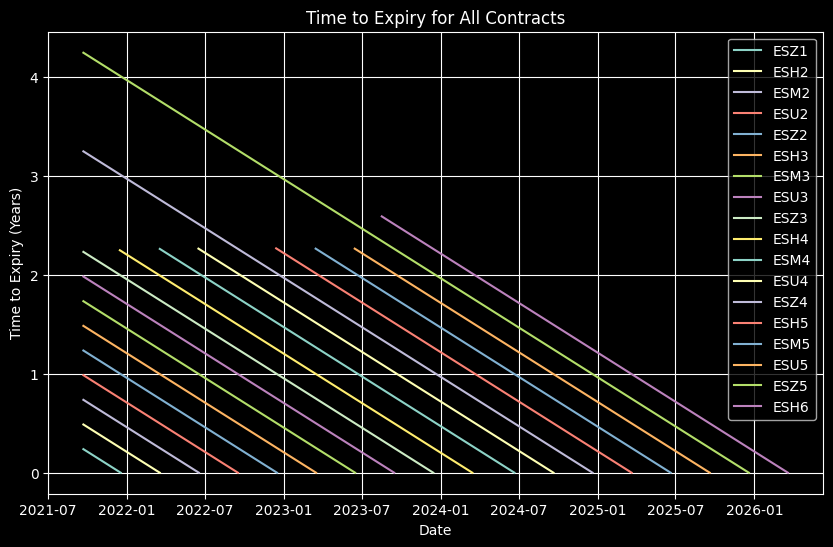

In [746]:
plt.figure(figsize=(10, 6))

for col in analysis_df['T'].columns:
    plt.plot(
        analysis_df.index,
        analysis_df['T'][col],
        label=col
    )

plt.xlabel("Date")
plt.ylabel("Time to Expiry (Years)")
plt.title("Time to Expiry for All Contracts")
plt.legend()
plt.grid(True)

plt.show()

In [747]:
# TO-DO List
# 1. start with a systematic short (Buy F1 -> Sell F2)
# roll it to the nearest contract before expiry (T-3, T-4, T-5)
# 2. determine the best time to roll, fair roll spread v.s. actual spread
# incorporate volume / open interest if possible
# 3. research the initial setting

In [748]:
# Initial setting (require research)
INITIAL_NAV = 100_000_000 # USD
MULTIPLIER = 50 # E-Mini Futures
T_COST = 2.5 # USD per contract per trade (commission only)

ROLL_WINDOW = 2 / 365 # Days before maturity (T-2)
# N_CONTRACTS # Number of contracts for hedging (Damien)

In [749]:
fut_price = analysis_df['PX'][futures]
fair_price = analysis_df['Fair'][futures]

In [750]:
T = analysis_df['T']

In [751]:
front_idx = 0

F = pd.Series(index=fut_price.index, dtype=object)

In [752]:
for i, date in enumerate(fut_price.index):
    front = futures[front_idx]
    # roll condition
    if T.loc[date, front] <= ROLL_WINDOW:
        if front_idx < len(futures) - 1:
            front_idx += 1

    # assign AFTER deciding
    F.iloc[i] = futures[front_idx]
print(futures[front_idx])

ESH6


In [753]:
F.to_csv('../data/backtest/F.csv')

In [754]:
positions = pd.DataFrame(0,
            index=fut_price.index,
            columns=futures
            )
for date in positions.index:
    positions.loc[date, F.loc[date]] = -1 # date, contract that we are shorting

positions.to_csv('../data/backtest/positions.csv')

In [755]:
trades = positions.diff().abs().sum(axis=1)
roll_dates = trades[trades==2]
roll_dates

Date
2021-12-15    2.0
2022-03-16    2.0
2022-06-15    2.0
2022-09-14    2.0
2022-12-14    2.0
2023-03-15    2.0
2023-06-14    2.0
2023-09-13    2.0
2023-12-13    2.0
2024-03-13    2.0
2024-06-20    2.0
2024-09-18    2.0
2024-12-18    2.0
2025-03-19    2.0
2025-06-18    2.0
2025-09-17    2.0
2025-12-17    2.0
dtype: float64

In [756]:
transaction_cost = trades * T_COST

In [757]:
price_diff = fut_price.diff()

raw_pnl = (
    positions.shift(1) * price_diff
).sum(axis=1) * MULTIPLIER
fut_price

contract,ESZ1,ESH2,ESM2,ESU2,ESZ2,ESH3,ESM3,ESU3,ESZ3,ESH4,ESM4,ESU4,ESZ4,ESH5,ESM5,ESU5,ESZ5,ESH6
Date,,,,,,,,,,,,,,,,,,
2021-09-21,4343.25,4335.75,4325.75,4321.25,4312.25,4303.50,4294.50,4295.00,4292.00,NaN,NaN,NaN,4284.50,NaN,NaN,NaN,4289.50,NaN
2021-09-22,4384.00,4376.50,4366.25,4360.50,4351.50,4342.50,4333.50,4334.00,4331.00,NaN,NaN,NaN,4323.50,NaN,NaN,NaN,4328.50,NaN
2021-09-23,4438.00,4430.50,4420.25,4412.75,4403.25,4393.75,4384.25,4384.50,4381.50,NaN,NaN,NaN,4374.00,NaN,NaN,NaN,4379.00,NaN
2021-09-24,4445.75,4438.25,4428.00,4419.00,4412.50,4403.75,4394.75,4395.25,4394.25,NaN,NaN,NaN,4396.75,NaN,NaN,NaN,4401.75,NaN
2021-09-27,4433.00,4425.50,4415.50,4408.50,4399.50,4390.75,4381.75,4382.25,4381.25,NaN,NaN,NaN,4383.75,NaN,NaN,NaN,4388.75,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6704.75
2026-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6721.75
2026-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6626.00


In [758]:
raw_pnl

Date
2021-09-21       0.0
2021-09-22   -2037.5
2021-09-23   -2700.0
2021-09-24    -387.5
2021-09-27     637.5
               ...  
2026-03-16   -3437.5
2026-03-17    -850.0
2026-03-18    4787.5
2026-03-19     837.5
2026-03-20     731.0
Length: 1120, dtype: float64

In [759]:
net_pnl = raw_pnl - transaction_cost
NAV = INITIAL_NAV + net_pnl.cumsum()
NAV

Date
2021-09-21    100000000.0
2021-09-22     99997962.5
2021-09-23     99995262.5
2021-09-24     99994875.0
2021-09-27     99995512.5
                 ...     
2026-03-16     99916252.5
2026-03-17     99915402.5
2026-03-18     99920190.0
2026-03-19     99921027.5
2026-03-20     99921758.5
Length: 1120, dtype: float64

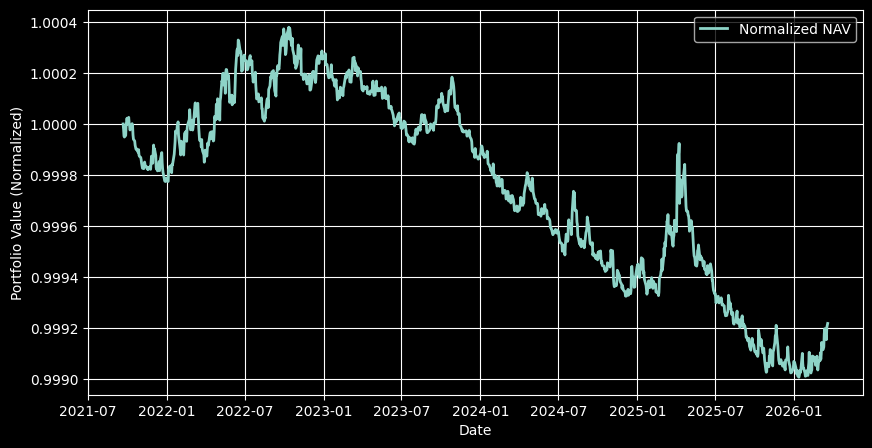

In [760]:
NAV_norm = NAV / NAV.iloc[0]
plt.figure(figsize=(10, 5))

plt.plot(NAV_norm.index, NAV_norm.values, label='Normalized NAV', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)

plt.show()

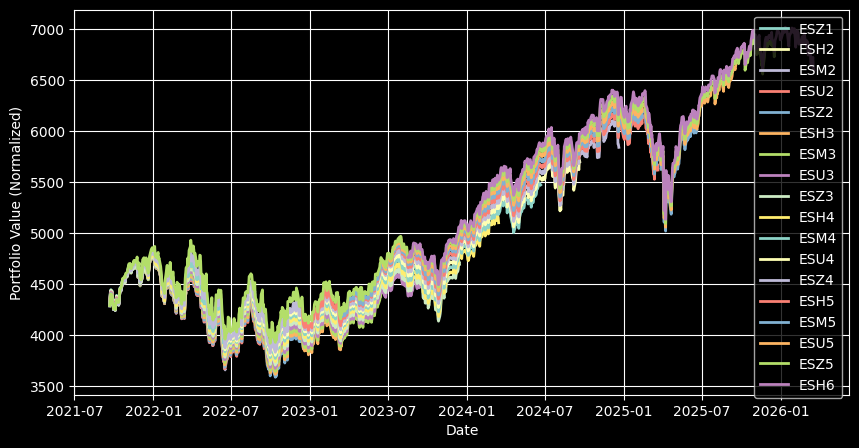

In [761]:
plt.figure(figsize=(10, 5))

for fut in futures:
    plt.plot(fut_price.index, fut_price[fut], label=fut, linewidth=2)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)

plt.show()

# we are shorting future but the future values goes up
# it makes sense that we result in a loss because we are doing systematic short

In [762]:
# 4 Fair roll analysis: Trading Strategies
positions = pd.DataFrame(0, index=fut_price.index, columns=fut_price.columns)

current_contract = F1.iloc[0]

for date in fut_price.index:
    near = F1.loc[date]
    far = F2.loc[date]

    fair = fair_price.loc[date, far] - fair_price.loc[date, near]
    actual = fut_price.loc[date, far] - fut_price.loc[date, near]

    tte = analysis_df.loc[date, ('T', near)]

    # FIX: don't use "in", use range
    if (2/365 <= tte <= 5/365) and (actual < fair):
        current_contract = far  # roll

    positions.loc[date, current_contract] = 1

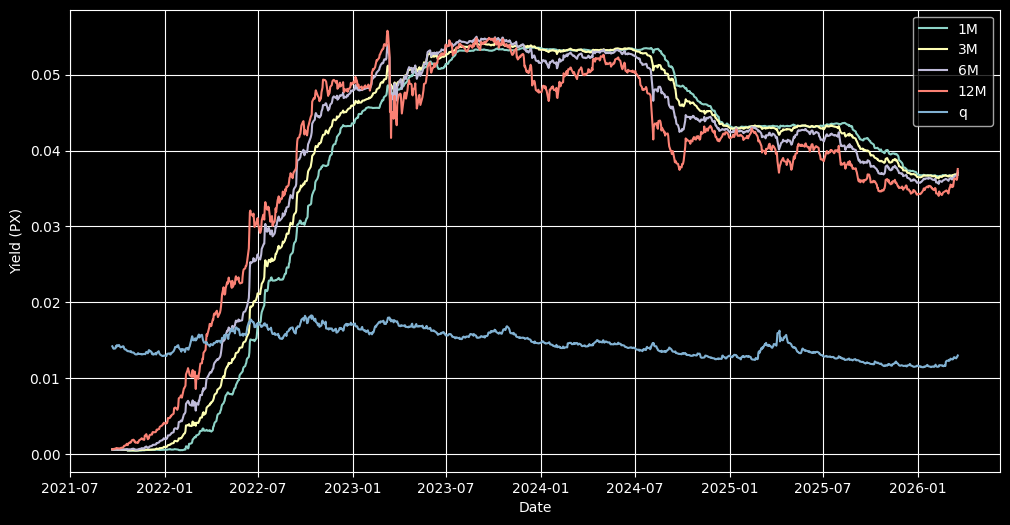

In [770]:
# interest rate and dividend yield
plt.figure(figsize=(12, 6))

for m in ['1M', '3M', '6M', '12M', 'q']:
    plt.plot(
        analysis_df.index,
        analysis_df['PX'][m],
        label=m
    )

plt.xlabel("Date")
plt.ylabel("Yield (PX)")
plt.legend()
plt.grid(True)

plt.show()

In [764]:
# define key tenors
y1m = analysis_df['PX']['1M']
y12m = analysis_df['PX']['12M']

# main inversion signal
inv_1m_12m = y1m > y12m
inv_dates = inv_1m_12m[inv_1m_12m].index
print(inv_dates[0])

2023-03-14 00:00:00


In [765]:
q = analysis_df['PX']['q']
r = analysis_df['PX']['1M']

backwardation = q > r
back_dates = backwardation[backwardation].index

In [766]:
# Observation
# 1. inverted yield curve happened at 2023-03-14
# 2. dividend yield is higher than short-term rate until 2022-07 (backwardation til 2022-07 -> contango)

In [767]:
# quantitative signal
front_idx = 0

F = pd.Series(index=fut_price.index, dtype=object)

rolling_spread = pd.DataFrame(
    index=fut_price.index,
    columns=["near", "far", "fair", "market", "difference", "zscore"]
)

In [768]:
# store signal history for z-score
signal_series = pd.Series(index=fut_price.index, dtype=float)

lookback = 20
z_threshold = 2.0

In [769]:
for i, date in enumerate(fut_price.index):

        # -------------------------
        # If last contract
        # -------------------------
        if front_idx >= len(futures) - 1:
            F.iloc[i] = futures[front_idx]
            continue

        near = futures[front_idx]
        far = futures[front_idx + 1]

        # -------------------------
        # Compute spreads
        # -------------------------
        fair = fair_price.loc[date, far] - fair_price.loc[date, near]
        market = fut_price.loc[date, far] - fut_price.loc[date, near]
        diff = market - fair

        rolling_spread.loc[date, ["near", "far"]] = [near, far]
        rolling_spread.loc[date, "fair"] = fair
        rolling_spread.loc[date, "market"] = market
        rolling_spread.loc[date, "difference"] = diff

        signal_series.loc[date] = diff

        # -------------------------
        # Z-score
        # -------------------------
        if i >= lookback:
            window = signal_series.iloc[i - lookback:i]

            mean = window.mean()
            std = window.std()

            z = (diff - mean) / (std + 1e-8)
        else:
            z = np.nan

        rolling_spread.loc[date, "zscore"] = z

        # -------------------------
        # Rolling decision
        # -------------------------
        T_now = T.loc[date, near]

        rolled = False
        roll_type = None

        # SIGNAL ROLL (T-10)
        if (T_now <= 14/365) and (not pd.isna(z)):
            if z > z_threshold:
                front_idx += 1
                rolled = True
                roll_type = "SIGNAL"

        # FORCED ROLL (T-3)
        if (not rolled) and (T_now <= 3/365):
            front_idx += 1
            rolled = True
            roll_type = "FORCED"

        # -------------------------
        # PRINT LOG
        # -------------------------
        if rolled:
            T_days = int(round(T_now * 365))

            # Adjust for weekends
            if T_days >= 14:
                T_days -= 4   # ~2 weekends
            elif T_days >= 7:
                T_days -= 2   # ~1 weekend

            print(
                f"{date.date()} | Roll ({roll_type}) | "
                f"T-{T_days} (business days) | {near} → {far} | "
                f"market={market:.2f} | fair={fair:.2f} | diff={diff:.2f} | z={z:.2f}"
            )

        # -------------------------
        # Record front contract
        # -------------------------
        F.iloc[i] = futures[front_idx]

2021-12-14 | Roll (FORCED) | T-3 (business days) | ESZ1 → ESH2 | market=-9.00 | fair=-14.65 | diff=5.65 | z=-3.16
2022-03-15 | Roll (FORCED) | T-3 (business days) | ESH2 → ESM2 | market=-8.25 | fair=-10.70 | diff=2.45 | z=-0.44
2022-06-13 | Roll (SIGNAL) | T-4 (business days) | ESM2 → ESU2 | market=3.00 | fair=-0.89 | diff=3.89 | z=3.36
2022-09-12 | Roll (SIGNAL) | T-4 (business days) | ESU2 → ESZ2 | market=19.25 | fair=16.82 | diff=2.43 | z=2.49
2022-12-13 | Roll (FORCED) | T-3 (business days) | ESZ2 → ESH3 | market=33.00 | fair=29.43 | diff=3.57 | z=-0.61
2023-03-07 | Roll (SIGNAL) | T-8 (business days) | ESH3 → ESM3 | market=37.25 | fair=32.82 | diff=4.43 | z=2.25
2023-06-09 | Roll (SIGNAL) | T-5 (business days) | ESM3 → ESU3 | market=44.00 | fair=39.28 | diff=4.72 | z=2.59
2023-09-08 | Roll (SIGNAL) | T-5 (business days) | ESU3 → ESZ3 | market=49.50 | fair=43.35 | diff=6.15 | z=2.81
2023-12-06 | Roll (SIGNAL) | T-7 (business days) | ESZ3 → ESH4 | market=50.25 | fair=43.94 | diff=6.